In [1]:
import numpy as np
import math
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
## Black Scholes
# C = S * N(d1) - K * exp(-rT) * N(d2)
# d1 = (ln(S / K) + (r + 0.5 * sigma^2) * T) / (sigma * sqrt(T))
# d2 = (ln(S / K) - (r + 0.5 * sigma^2) * T) / (sigma * sqrt(T)) = d1 - sigma * sqrt(T)
# C: Call option price
# S: Stock price
# K: Exercise price
# r: risk free rate of returnm
# T: Time to expiration
# sigma: volatility, usually standard deviation
# N(): cdf, of normal distribution

In [3]:
def calculateD1(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma):
    numerator1 = math.log(stockPrice / exercisePrice)
    numerator2 = (rateOfReturn + 0.5 * sigma ** 2) * timeToExpiration
    denominator = sigma * math.sqrt(timeToExpiration)
    
    return (numerator1 + numerator2) / denominator

In [4]:
def calculateD2(sigma, timeToExpiration, d1):
    return d1 - sigma * math.sqrt(timeToExpiration)

# alternate
#def calculateD1(stockPrice, ExercisePrice, rateOfReturn, timeToExpiration, sigma):
#    numerator1 = math.log(stockPrice / ExercisePrice)
#    numerator2 = (rateOfReturn + 0.5 * sigma ** 2) * T
#    denominator = sigma * math.sqrt(T)
    
#    return (numerator1 - numerator2) / denominator

In [5]:
def calculateCallOptionPrice(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma):
    d1 = calculateD1(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma)
    d2 = calculateD2(sigma, timeToExpiration, d1)
    
    norm1 = stats.norm.cdf(d1)
    norm2 = stats.norm.cdf(d2)
    
    num1 = stockPrice * norm1
    num2 = exercisePrice * norm2 * (math.exp(-1 * rateOfReturn * timeToExpiration))
    
    return num1 - num2

In [6]:
def calculatePutOptionPrice(callOptionPrice, stockPrice, exercisePrice, rateOfReturn, timeToExpiration):
    discountedFuturePrice = exercisePrice * math.exp(-1 * rateOfReturn * timeToExpiration)
    
    return callOptionPrice -stockPrice + discountedFuturePrice

In [7]:
# parameters
S = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

callPrice = calculateCallOptionPrice(S, K, r, T, sigma)

In [8]:
print(callPrice)

10.450583572185572


In [9]:
putPrice = calculatePutOptionPrice(callPrice, S, K, r, T)

In [10]:
print(putPrice)

5.573526022256971


In [11]:
# Put-Call Parity:  C - P  =  S - K * exp(-r*T)
lhs = callPrice - putPrice
rhs = S - K * math.exp(-r * T)
print(f"C - P          = {lhs:.6f}")
print(f"S - K·exp(-rT) = {rhs:.6f}")
print(f"Parity holds:    {abs(lhs - rhs) < 1e-10}")

C - P          = 4.877058
S - K·exp(-rT) = 4.877058
Parity holds:    True


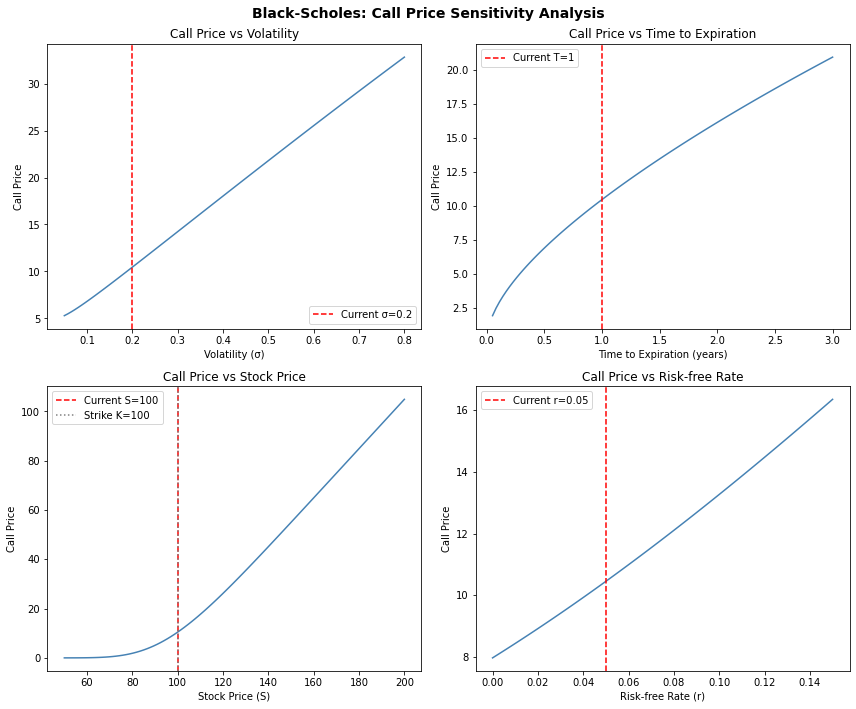

In [12]:
# Sensitivity of call price to each parameter (others held at base values)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sigmas = np.linspace(0.05, 0.8, 100)
axes[0, 0].plot(sigmas, [calculateCallOptionPrice(S, K, r, T, s) for s in sigmas], color='steelblue')
axes[0, 0].axvline(sigma, color='red', linestyle='--', label=f'Current σ={sigma}')
axes[0, 0].set_xlabel('Volatility (σ)')
axes[0, 0].set_ylabel('Call Price')
axes[0, 0].set_title('Call Price vs Volatility')
axes[0, 0].legend()

times = np.linspace(0.05, 3.0, 100)
axes[0, 1].plot(times, [calculateCallOptionPrice(S, K, r, t, sigma) for t in times], color='steelblue')
axes[0, 1].axvline(T, color='red', linestyle='--', label=f'Current T={T}')
axes[0, 1].set_xlabel('Time to Expiration (years)')
axes[0, 1].set_ylabel('Call Price')
axes[0, 1].set_title('Call Price vs Time to Expiration')
axes[0, 1].legend()

stock_prices = np.linspace(50, 200, 100)
axes[1, 0].plot(stock_prices, [calculateCallOptionPrice(s, K, r, T, sigma) for s in stock_prices], color='steelblue')
axes[1, 0].axvline(S, color='red', linestyle='--', label=f'Current S={S}')
axes[1, 0].axvline(K, color='gray', linestyle=':', label=f'Strike K={K}')
axes[1, 0].set_xlabel('Stock Price (S)')
axes[1, 0].set_ylabel('Call Price')
axes[1, 0].set_title('Call Price vs Stock Price')
axes[1, 0].legend()

rates = np.linspace(0.0, 0.15, 100)
axes[1, 1].plot(rates, [calculateCallOptionPrice(S, K, rate, T, sigma) for rate in rates], color='steelblue')
axes[1, 1].axvline(r, color='red', linestyle='--', label=f'Current r={r}')
axes[1, 1].set_xlabel('Risk-free Rate (r)')
axes[1, 1].set_ylabel('Call Price')
axes[1, 1].set_title('Call Price vs Risk-free Rate')
axes[1, 1].legend()

plt.suptitle('Black-Scholes: Call Price Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
### call price relations with variable
##       Var                 Increase or Decrease               call Price
#       sigma                         I                             I
#         T                           I                             I
#         S                         I(>K)                           I